### 0️. Importar Librerias

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split,GridSearchCV)

from sklearn.preprocessing import (StandardScaler)

from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score,
    accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,
    classification_report)

from sklearn.linear_model import (LinearRegression,LogisticRegression,Ridge,Lasso,ElasticNet)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Para que se muestren todas las columnas al inspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

In [3]:
from framework import sp_carga_exploracion as sc
from framework import sp_limpieza_transformacion as sl
from framework import sp_eda as se
from framework import sp_abtest as sb
from framework import sp_modelado as sm

### 1️. Cargar archivos csv Regresión

#### cargar_csv X_reg

In [4]:
ruta = '../data/processed/X_reg.csv'
X_reg = sm.cargar_csv(ruta)

CSV CARGADO
Archivo: ../data/processed/X_reg.csv
Filas:   1000
Columnas: 18


In [5]:
type(X_reg)

pandas.DataFrame

#### cargar_csv y_reg

In [6]:
ruta = '../data/processed/y_reg.csv'
y_reg = sm.cargar_csv(ruta,squeeze=True)

CSV CARGADO
Archivo: ../data/processed/y_reg.csv
Filas:   1000
Columnas: 1 (Series)


In [7]:
type(y_reg)

pandas.Series

### 6. División Train/Test

train_test()

In [8]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = (
    sm.train_test(X_reg, y_reg))

In [9]:
print(X_train_reg.shape)
print(X_test_reg.shape)

print(y_train_reg.shape)
print(y_test_reg.shape)

(800, 18)
(200, 18)
(800,)
(200,)


### 7. Estandarización

In [10]:
X_train_reg.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,800.0,10.05,4.90,1.0,6.55,9.96,13.36,25.0
nota_anterior,800.0,70.04,14.86,30.0,59.55,70.17,80.64,100.0
tasa_asistencia,800.0,73.99,18.16,20.0,61.45,75.05,88.18,100.0
horas_sueno,800.0,7.01,1.32,4.0,6.15,7.01,7.80,10.0
edad,800.0,23.52,3.46,18.0,21.00,24.00,26.00,29.0
tiene_tutor_ml,800.0,0.40,0.49,0.0,0.00,0.00,1.00,1.0
nivel_dificultad_dificil,800.0,0.18,0.38,0.0,0.00,0.00,0.00,1.0
nivel_dificultad_facil,800.0,0.31,0.46,0.0,0.00,0.00,1.00,1.0
nivel_dificultad_medio,800.0,0.51,0.50,0.0,0.00,1.00,1.00,1.0
horario_estudio_preferido_desconocido,800.0,0.10,0.30,0.0,0.00,0.00,0.00,1.0


#### estandarizar()

Descartamos:
Binarias, One Hot y tv

In [11]:
# columnas_continuas
columnas_escalar = ['horas_estudio_semanal','nota_anterior','tasa_asistencia','horas_sueno','edad']

In [12]:
X_train_reg, X_test_reg, scaler_reg = sm.estandarizar(
X_train_reg,
X_test_reg,
columnas=columnas_escalar
)

In [13]:
X_train_reg[
    columnas_escalar
].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,800.0,0.0,1.0,-1.85,-0.72,-0.02,0.67,3.05
nota_anterior,800.0,0.0,1.0,-2.70,-0.71,0.01,0.71,2.02
tasa_asistencia,800.0,-0.0,1.0,-2.98,-0.69,0.06,0.78,1.43
horas_sueno,800.0,-0.0,1.0,-2.28,-0.65,0.00,0.60,2.27
edad,800.0,-0.0,1.0,-1.60,-0.73,0.14,0.72,1.59


✅ Entrenamiento usando únicamente Train.

✅ Test transformado con el scaler de Train.

✅ Sin fuga de información.

✅ Variables continuas estandarizadas.

✅ Binarias y One Hot intactas.

Se aplica StandardScaler sobre las variables continuas:
 - horas_estudio_semanal - nota_anterior - tasa_asistencia - horas_sueno - edad 
 
 Las variables binarias y las obtenidas mediante One Hot Encoding se mantienen en su escala original (0/1). La media de las variables escaladas se aproxima a 0 y la desviación estándar a 1.

### 8. Entrenamiento Incial

#### entrenar_evaluar_regresion()

In [14]:
modelo = LinearRegression()

modelo, metricas, y_pred = (
    sm.entrenar_evaluar_regresion(
        modelo,
        X_train_reg,
        X_test_reg,
        y_train_reg,
        y_test_reg
    )
)

metricas

{'MAE': 5.815748560046074,
 'MSE': 52.512367100105806,
 'RMSE': np.float64(7.246541733827647),
 'R2': 0.35803572358416147}

Conclusiones del modelo base: Regresión Lineal

Se entrena un modelo de Regresión Lineal utilizando las variables predictoras preparadas durante el preprocesamiento.

Resultados obtenidos

| Métrica | Valor |
|----------|--------:|
| MAE | 5.82 |
| MSE | 52.51 |
| RMSE | 7.25 |
| R² | 0.358 |

 Interpretación

- El modelo explica aproximadamente un **35,8% de la variabilidad** de la variable objetivo (`nota_final`).
- El error absoluto medio (**MAE**) es de aproximadamente **5,8 puntos**, lo que indica que las predicciones difieren de la nota real en unos 6 puntos de media.
- El error cuadrático medio (**RMSE**) es de **7,25 puntos**, penalizando especialmente las predicciones más alejadas de la realidad.
- El resultado constituye una **línea base (baseline)** sobre la que comparar modelos más avanzados como Ridge, Lasso o ElasticNet.

Valoración

El modelo ofrece un rendimiento razonable para una primera aproximación, aunque todavía existe una parte importante de la variabilidad de las notas finales que no está siendo explicada por las variables incluidas en el modelo.

Los siguientes pasos consistirán en:

1. Validar el comportamiento entre train y test.
2. Comparar distintos modelos de regresión.
3. Optimizar hiperparámetros si procede.
4. Analizar la importancia de las variables predictoras.

### 9. Métricas

#### metricas_regresion()

In [17]:
sm.metricas_regresion(
    y_test_reg,
    y_pred
)

{'MAE': 5.815748560046074,
 'MSE': 52.512367100105806,
 'RMSE': np.float64(7.246541733827647),
 'R2': 0.35803572358416147}

### 10. Validacion

#### comparar_train_test()

In [18]:
sm.comparar_train_test(
    modelo,
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg,
    tipo='regresion'
)

R² Train: 0.3916
R² Test : 0.3580


Conclusiones de validación

Se compara el rendimiento del modelo de Regresión Lineal sobre los conjuntos de entrenamiento y prueba.

| Métrica | Valor |
|----------|--------:|
| R² Train | 0.392 |
| R² Test | 0.358 |

Interpretación

La diferencia entre el rendimiento obtenido en entrenamiento y en prueba es reducida (≈ 0,034 puntos de R²).

Esto sugiere que el modelo generaliza razonablemente bien sobre datos no vistos y no muestra evidencias claras de sobreajuste (*overfitting*).

Aunque la capacidad explicativa del modelo es moderada (R² ≈ 0,36), el comportamiento entre train y test es estable, por lo que constituye una línea base sólida para comparar modelos más avanzados como Ridge, Lasso y ElasticNet.

### 11. Comparación de modelos

#### comparar_modelos()

In [19]:
sm.comparar_modelos(
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg,
    tipo='regresion')

,R2_train,R2_test,MAE_test,RMSE_test
Linear,0.3916,0.3580,5.8157,7.2465
Ridge,0.3916,0.3582,5.8160,7.2456
Lasso,0.3870,0.3679,5.8385,7.1907
ElasticNet,0.3882,0.3670,5.8381,7.1960


Conclusiones de la comparación de modelos

Se comparan distintos modelos lineales de regresión sobre el mismo conjunto de entrenamiento y prueba.

| Modelo | R² Test | MAE | RMSE |
|----------|--------:|--------:|--------:|
| Linear | 0.3580 | 5.8157 | 7.2465 |
| Ridge | 0.3582 | 5.8160 | 7.2456 |
| Lasso | **0.3679** | 5.8385 | **7.1907** |
| ElasticNet | 0.3670 | 5.8381 | 7.1960 |

#### Interpretación

- Todos los modelos muestran un comportamiento estable entre entrenamiento y prueba.
- Ridge apenas mejora el rendimiento de la Regresión Lineal.
- Lasso y ElasticNet obtienen los mejores valores de R² y RMSE.
- El mejor resultado global corresponde a **Lasso**, con un R² de 0.368 y el menor RMSE observado.

#### Conclusión

Las relaciones entre las variables predictoras y la variable objetivo parecen ser moderadamente lineales.

Los modelos regularizados (especialmente Lasso) consiguen una ligera mejora respecto a la Regresión Lineal clásica, lo que sugiere que algunas variables pueden aportar ruido o información redundante.

A falta de una optimización de hiperparámetros, **Lasso se posiciona como el modelo candidato más prometedor para continuar el análisis**.

### 12. Optimización

 #### grid_search()

##### modelo Lasso

In [20]:
modelo = Lasso()

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}

mejor_modelo = sm.grid_search(
    modelo,
    param_grid,
    X_train_reg,
    y_train_reg,
    scoring='r2'
)


Mejores parámetros:
{'alpha': 0.1}


 Conclusiones de la optimización

Se realiza una búsqueda de hiperparámetros mediante `GridSearchCV` sobre el modelo Lasso.

#### Resultado

Mejor parámetro encontrado:

```python
alpha = 0.1
```

#### Interpretación

El valor seleccionado coincide con el utilizado inicialmente durante la comparación de modelos.

Por tanto, la optimización no produce mejoras adicionales sobre el modelo previamente evaluado.

#### Conclusión

Se confirma que el modelo Lasso con `alpha=0.1` es la mejor alternativa dentro del rango de parámetros analizado y se mantiene como candidato para el entrenamiento final.

### 13. Entrenamiento Final

#### entrenar_final()

In [21]:
modelo_final = Lasso(alpha=0.1)

modelo_final = sm.entrenar_final(
    modelo_final,
    X_reg,
    y_reg
)

### 14. Interpretación

 #### importancia_variables()

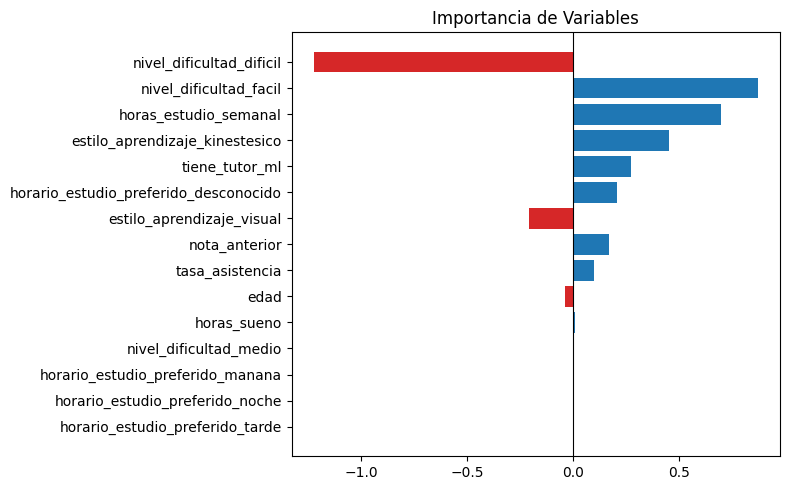

,variable,importancia
6,nivel_dificultad_dificil,-1.223250
7,nivel_dificultad_facil,0.873389
0,horas_estudio_semanal,0.701770
15,estilo_aprendizaje_kinestesico,0.452687
5,tiene_tutor_ml,0.272774
9,horario_estudio_preferido_desconocido,0.210185
17,estilo_aprendizaje_visual,-0.205391
1,nota_anterior,0.170306
2,tasa_asistencia,0.097776
4,edad,-0.037180


In [22]:
sm.importancia_variables(
    modelo_final,
    X_reg.columns
)

Interpretación de variables (Lasso)

Se analiza la importancia de las variables utilizando el modelo Lasso optimizado (`alpha=0.1`).

#### Variables con mayor impacto

| Variable | Coeficiente |
|-----------|-----------:|
| nivel_dificultad_dificil | -1.223 |
| nivel_dificultad_facil | 0.873 |
| horas_estudio_semanal | 0.702 |
| estilo_aprendizaje_kinestesico | 0.453 |
| tiene_tutor_ml | 0.273 |

#### Variables con impacto moderado

| Variable | Coeficiente |
|-----------|-----------:|
| horario_estudio_preferido_desconocido | 0.210 |
| estilo_aprendizaje_visual | -0.205 |
| nota_anterior | 0.170 |
| tasa_asistencia | 0.098 |

#### Variables con impacto reducido o nulo

| Variable | Coeficiente |
|-----------|-----------:|
| edad | -0.037 |
| horas_sueno | 0.010 |
| nivel_dificultad_medio | 0.000 |
| horario_estudio_preferido_manana | 0.000 |
| horario_estudio_preferido_noche | 0.000 |
| horario_estudio_preferido_tarde | 0.000 |

#### Conclusiones

- La dificultad percibida del curso aparece como el factor con mayor peso en la predicción.
- Un mayor número de horas de estudio semanal se asocia con mejores resultados académicos.
- Disponer de tutor mejora ligeramente la predicción de la nota final.
- Edad y horas de sueño tienen una influencia prácticamente nula.
- Lasso elimina automáticamente algunas variables asignándoles coeficiente cero, indicando que aportan poca o ninguna información adicional al modelo.
`

### 15. Simulación

##### describe

In [24]:
X_train_reg.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,800.0,0.00,1.00,-1.85,-0.72,-0.02,0.67,3.05
nota_anterior,800.0,0.00,1.00,-2.70,-0.71,0.01,0.71,2.02
tasa_asistencia,800.0,-0.00,1.00,-2.98,-0.69,0.06,0.78,1.43
horas_sueno,800.0,-0.00,1.00,-2.28,-0.65,0.00,0.60,2.27
edad,800.0,-0.00,1.00,-1.60,-0.73,0.14,0.72,1.59
tiene_tutor_ml,800.0,0.40,0.49,0.00,0.00,0.00,1.00,1.00
nivel_dificultad_dificil,800.0,0.18,0.38,0.00,0.00,0.00,0.00,1.00
nivel_dificultad_facil,800.0,0.31,0.46,0.00,0.00,0.00,1.00,1.00
nivel_dificultad_medio,800.0,0.51,0.50,0.00,0.00,1.00,1.00,1.00
horario_estudio_preferido_desconocido,800.0,0.10,0.30,0.00,0.00,0.00,0.00,1.00


##### `horas_estudio_semanal`

In [28]:
X_train_reg['horas_estudio_semanal'].describe().round(2)

count    800.00
mean       0.00
std        1.00
min       -1.85
25%       -0.72
50%       -0.02
75%        0.67
max        3.05
Name: horas_estudio_semanal, dtype: float64

In [29]:
sm.simular_variable(
    modelo_final,
    X_reg,
    columna='horas_estudio_semanal',
    valores=[-1.5,-1,0,1,2,3]
)

,horas_estudio_semanal,prediccion
0,-1.5,63.32
1,-1.0,63.67
2,0.0,64.37
3,1.0,65.07
4,2.0,65.78
5,3.0,66.48


Simulación de escenarios

Se analiza el efecto de la variable `horas_estudio_semanal` sobre la nota final predicha por el modelo Lasso.

| Horas de estudio (estandarizada) | Nota predicha |
|----------|--------:|
| -1.5 | 63.32 |
| -1.0 | 63.67 |
| 0.0 | 64.37 |
| 1.0 | 65.07 |
| 2.0 | 65.78 |
| 3.0 | 66.48 |

Interpretación

El modelo muestra una relación positiva entre las horas de estudio semanal y la nota final.

A medida que aumenta el tiempo dedicado al estudio, la nota estimada también tiende a aumentar.

Entre los escenarios simulados más extremos, la diferencia de rendimiento supera los 3 puntos, lo que confirma que las horas de estudio constituyen uno de los factores con mayor capacidad predictiva dentro del modelo.

##### `tiene_tutor_ml`

In [30]:
sm.simular_variable(
    modelo_final,
    X_reg,
    columna='tiene_tutor_ml',
    valores=[0,1]
)

,tiene_tutor_ml,prediccion
0,0,71.33
1,1,71.60


Simulación de escenarios: Tutor

Se analiza el efecto de disponer o no de tutor sobre la nota final predicha por el modelo Lasso.

| Tiene tutor | Nota predicha |
|-------------|--------------:|
| No (0) | 71.33 |
| Sí (1) | 71.60 |

 
 Interpretación

El modelo estima una mejora aproximada de 0,27 puntos en la nota final para los estudiantes que disponen de tutor, manteniendo constantes el resto de variables.

Aunque el efecto es positivo, su impacto es relativamente reducido en comparación con otras variables del modelo, como la dificultad percibida del curso o las horas de estudio semanal.

Conclusión

La presencia de un tutor contribuye favorablemente a la predicción del rendimiento académico, aunque por sí sola no explica una parte importante de la variabilidad observada en las notas finales.

### Guardar Modelo 

#### guardar_modelo()

In [32]:
sm.guardar_modelo(
    modelo_final,
    '../data/processed/lasso_regresion.pkl'
)

Modelo guardado en: ../data/processed/lasso_regresion.pkl


### Conclusión final del modelo de regresión



Se entrenó y evaluó un modelo Lasso para predecir la variable `nota_final`.

Rendimiento final

- Modelo seleccionado: Lasso
- Alpha óptimo: 0.1
- R² Test: 0.368
- RMSE: 7.19
- MAE: 5.84

Hallazgos principales

- Las horas de estudio semanal muestran una relación positiva con la nota final.
- La dificultad del curso aparece como uno de los factores más influyentes del modelo.
- La disponibilidad de tutor presenta un efecto positivo, aunque moderado.
- Edad y horas de sueño aportan una capacidad predictiva muy limitada.

Validación

La diferencia entre Train y Test es reducida, por lo que no se observan evidencias significativas de sobreajuste.

Resultado

El modelo queda guardado y preparado para futuras predicciones.